In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
import tensorflow as tf

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [3]:
df = pd.read_csv("speech_therapy_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,Child_ID,Age,Gender,Speech_Error,Severity,Sessions_Attended,Practice_Minutes_Per_Day,Parent_Support,Pronunciation_Score,Improvement,Recommended_Exercise
0,1001,5,Male,TH,Low,10,45,Low,98,High,TH_Sound_Practice
1,1002,4,Male,R,Low,8,45,Medium,98,High,R_Sound_Practice
2,1003,8,Male,S,Medium,7,20,High,55,Medium,S_Sound_Practice
3,1004,5,Male,L,Low,13,5,High,61,Medium,L_Sound_Practice
4,1005,10,Male,General,Low,13,10,Low,84,High,General_Pronunciation


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Child_ID                  1000 non-null   int64
 1   Age                       1000 non-null   int64
 2   Gender                    1000 non-null   str  
 3   Speech_Error              1000 non-null   str  
 4   Severity                  1000 non-null   str  
 5   Sessions_Attended         1000 non-null   int64
 6   Practice_Minutes_Per_Day  1000 non-null   int64
 7   Parent_Support            1000 non-null   str  
 8   Pronunciation_Score       1000 non-null   int64
 9   Improvement               1000 non-null   str  
 10  Recommended_Exercise      1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [6]:
df.describe()

,Child_ID,Age,Sessions_Attended,Practice_Minutes_Per_Day,Pronunciation_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,8.025000,7.828000,25.110000,66.276000
std,288.819436,2.533139,3.244525,12.866758,18.767633
min,1001.000000,4.000000,2.000000,5.000000,11.000000
25%,1250.750000,6.000000,6.000000,15.000000,52.000000
50%,1500.500000,8.000000,8.000000,25.000000,67.000000
75%,1750.250000,10.000000,10.000000,35.000000,80.000000
max,2000.000000,12.000000,15.000000,45.000000,98.000000


In [7]:
print(df.isnull().sum())

Child_ID                    0
Age                         0
Gender                      0
Speech_Error                0
Severity                    0
Sessions_Attended           0
Practice_Minutes_Per_Day    0
Parent_Support              0
Pronunciation_Score         0
Improvement                 0
Recommended_Exercise        0
dtype: int64


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
# Remove Child_ID column

df = df.drop("Child_ID", axis=1)

print(df.head())

   Age Gender Speech_Error Severity  Sessions_Attended  \
0    5   Male           TH      Low                 10   
1    4   Male            R      Low                  8   
2    8   Male            S   Medium                  7   
3    5   Male            L      Low                 13   
4   10   Male      General      Low                 13   

   Practice_Minutes_Per_Day Parent_Support  Pronunciation_Score Improvement  \
0                        45            Low                   98        High   
1                        45         Medium                   98        High   
2                        20           High                   55      Medium   
3                         5           High                   61      Medium   
4                        10            Low                   84        High   

    Recommended_Exercise  
0      TH_Sound_Practice  
1       R_Sound_Practice  
2       S_Sound_Practice  
3       L_Sound_Practice  
4  General_Pronunciation  


In [12]:
# Separate Features and Target

X = df.drop("Recommended_Exercise", axis=1)
y = df["Recommended_Exercise"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 9)
Target Shape: (1000,)


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in X.columns:
    if X[column].dtype == "object" or X[column].dtype == "string":
        encoder = LabelEncoder()
        X[column] = encoder.fit_transform(X[column].astype(str))
        label_encoders[column] = encoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Encoding Completed Successfully")
print(X.head())

Encoding Completed Successfully
   Age  Gender  Speech_Error  Severity  Sessions_Attended  \
0    5       1             4         1                 10   
1    4       1             2         1                  8   
2    8       1             3         2                  7   
3    5       1             1         1                 13   
4   10       1             0         1                 13   

   Practice_Minutes_Per_Day  Parent_Support  Pronunciation_Score  Improvement  
0                        45               1                   98            0  
1                        45               2                   98            0  
2                        20               0                   55            2  
3                         5               0                   61            2  
4                        10               1                   84            0  


In [14]:
print(X.dtypes)

Age                         int64
Gender                      int64
Speech_Error                int64
Severity                    int64
Sessions_Attended           int64
Practice_Minutes_Per_Day    int64
Parent_Support              int64
Pronunciation_Score         int64
Improvement                 int64
dtype: object


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (800, 9)
Testing Shape: (200, 9)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [17]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 9)
X_test  : (200, 9)
y_train : (800,)
y_test  : (200,)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [19]:
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("Number of Classes:", num_classes)

Number of Classes: 5


In [20]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation="relu"))

model.add(Dense(16, activation="relu"))

model.add(Dense(num_classes, activation="softmax"))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,333 (13.02 KB)

 Trainable params: 3,333 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [23]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2675 - loss: 1.5962 - val_accuracy: 0.3700 - val_loss: 1.5176
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3862 - loss: 1.4270 - val_accuracy: 0.4150 - val_loss: 1.3529
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 1.2023 - val_accuracy: 0.6100 - val_loss: 1.0847
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6700 - loss: 0.8780 - val_accuracy: 0.8200 - val_loss: 0.7170
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9137 - loss: 0.5178 - val_accuracy: 0.9450 - val_loss: 0.4036
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9787 - loss: 0.2900 - val_accuracy: 0.9850 - val_loss: 0.2323
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9912 - loss: 0.1726 - val_accuracy: 0.9950 - val_loss: 0.1516
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.1062 - val_accuracy: 0.9950 - val_loss

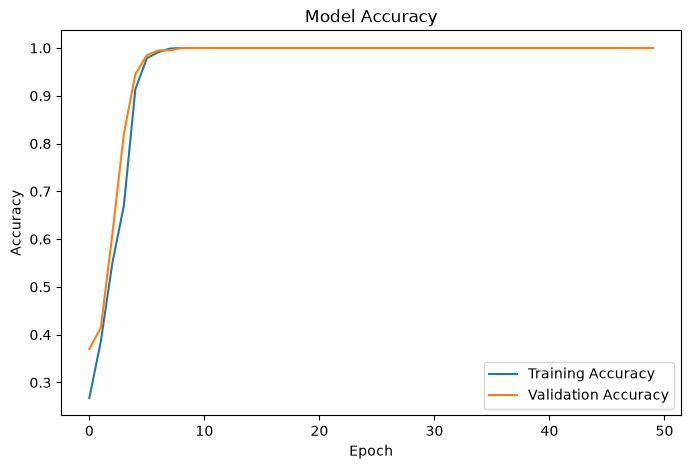

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [25]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 6.3143e-04
Test Loss : 0.0006314305937848985
Test Accuracy : 1.0


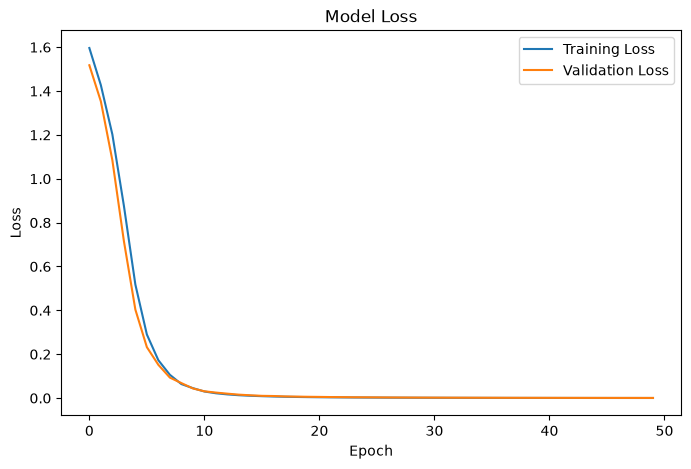

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [27]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        53
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        35

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



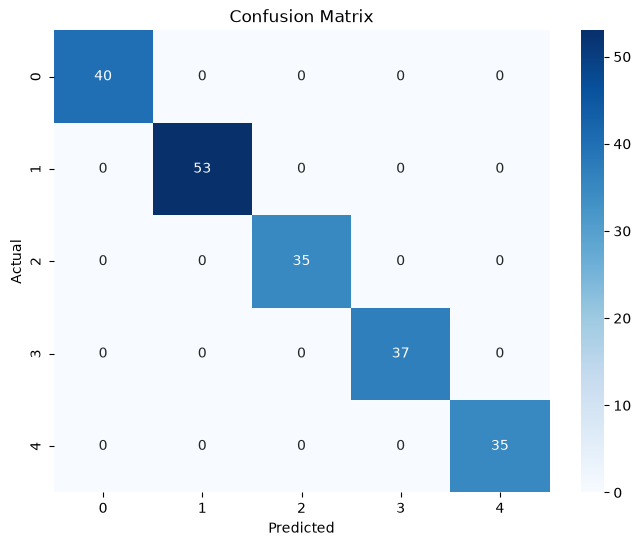

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
model.save("speech_therapy_ann_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [31]:
new_child = np.array([[

7,      # Age
1,      # Gender
2,      # Speech_Error
1,      # Severity
10,     # Sessions_Attended
30,     # Practice_Minutes_Per_Day
2,      # Parent_Support
75,     # Pronunciation_Score
1       # Improvement

]])

new_child = scaler.transform(new_child)

prediction = model.predict(new_child)

predicted_class = np.argmax(prediction)

exercise = target_encoder.inverse_transform([predicted_class])

print("Recommended Exercise :", exercise[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Recommended Exercise : R_Sound_Practice
